# LUBS5056M Python Programming for Finance Final Assessment -- Stock Market Analysis and Forecasting [100 Marks]  

## Introduction  
In this assignment, you will work with real-world stock market data obtained through the [`yfinance`](https://pypi.org/project/yfinance/) Python library to analyse price movements and develop predictive models. You will choose three companies or indices of interest and retrieve their historical price data, which you will use for exploratory data analysis, technical analysis, and forecasting.  

The goal of this assignment is to give you hands-on experience with financial time-series analysis, combining statistical and machine learning approaches. You will work through several stages of exploration, feature engineering, and modelling, including:  

- Conducting exploratory data analysis (EDA) to identify trends, volatility patterns, and relationships between technical indicators.  
- Creating visualisations to highlight insights and technical features such as moving averages, volatility bands, and other relevant charts.  
- Implementing and interpreting the Moving Average Convergence Divergence (MACD) indicator.  
- Building predictive models, including a multilayer perceptron (MLP) and an ARIMA model, to forecast future prices.  
- Producing a concise video presentation aimed at a technical audience, explaining the modelling approach, key analytical choices, and interpretation of results.
- Comparing the performance of statistical and machine learning models and distilling the results into a non‑technical executive report aimed at informing decision‑making.

This assignment is designed to strengthen your understanding of handling financial market data, applying forecasting techniques, and critically evaluating model results in a practical investment context. You will submit your work as a Jupyter Notebook, which should include both code and written analysis, as well as a separeate video recording of a presentation the details of which is given later in this Notebook.

The notebook contains a structured set of tasks, each with a dedicated code cell for you to implement your solution. These are designed to guide you through the assignment while leaving space for you to complete the required functionality. The notebook is divided into parts. Please attempt all parts and provide your written analysis where prompted (add Markdown cells where relevant to report findings, and/or answer questions). You may add or remove cells to organise your work as needed, but the overall structure and flow of the notebook should be preserved. Please also do not remove any of the assingment specification cells.

**Note:** You are not limited to techniques taught in lectures or provided in module notes. In Python, and programming in general, there are many valid ways to achieve the same result. You are encouraged to explore and think independently, but your solutions will be assessed on correctness, validity, and relevance to the tasks.  

### General Requirements  

**Notebook Execution and File Handling:**  
- **Ensure that all cells are run**: All cells should contain the expected outputs before submission.  
- **Ensure the notebook is fully runnable**: The entire notebook should run without errors from top to bottom.  
    - You should **not submit the datasets** as part of your submission.  
    - Save any processed datasets (e.g., cleaned CSVs) so that your notebook can reload them without repeated API calls.  
- **File names should be consistent** with those you define in the notebook.  

**Code Quality and Structure:**  
- **Use meaningful variable names**: Avoid single-letter or unclear variable names.  
- **Include inline comments**: Document the purpose of important steps in your code.  
- **Use modularity where appropriate**: Avoid redundancy by using functions for repeated processes.  
- **Follow good coding practices**: Keep your code clean and consistent in style.  

    > Note: Poor coding practices (e.g. unreadable structure, inconsistent naming, lack of comments, or excessive redundancy) may result in a penalty of **up to 5 marks**.

**Analysis and Interpretation:**  
- **Use markdown for explanations**: Provide written analysis and interpretation using markdown cells.  
- **Visualisations should be clear and labelled**: Include titles, axis labels, legends, and ensure readability.  

### Submission

Submit the following items via **Minerva** before the deadline. All file names must be your **student ID**.

1.  Your completed Jupyter Notebook (this file) in `.ipynb` format. Ensure that all cells have been run and that all outputs are visible.
2.  The recorded video of your presentation.
3.  The presentation slides in either PowerPoint or PDF format.

- Note: You should not submit any data files.

### Notebook Structure and Mark Allocation

This notebook is divided into the following parts, with the corresponding marks for each section shown in brackets:

1. Loading stock data and handling missing values [8 marks]  
2. Visualising stock prices and technical indicators [8 marks]  
3. MACD calculation and interpretation [14 marks]  
4. MLP forecasting [20 marks]  
5. ARIMA forecasting (static and dynamic parameters) [20 marks]  
6. Comparing ARIMA and MLP [10 marks]  
7. Executive summary and recommendation [10 marks] 
8. Video Presentation [10 marks]

**Note:** Write your student ID in the cell below by replacing `<student_id_here>` with your student ID.

In [1]:
# Student ID: 201971652

## 1. Loading Stock Data from Yahoo Finance

In this step, you will retrieve historical stock price data for *three companies or indices* of your choice using the [`yfinance`](https://pypi.org/project/yfinance/) Python library. Select stocks that interest you or that you believe might show interesting patterns for analysis. You should ensure that the chosen stocks have sufficient trading history and are relevant for the rest of the assignment.

You may choose to:
- Fetch each stock *separately* into its own `DataFrame`, or  
- Fetch *all stocks at once* into a single `DataFrame` with a *multi-level column index* (where level 0 contains fields like `Open`, `Close`, `Volume`, and level 1 contains the ticker symbols).  

Either approach is acceptable, but you must be consistent when cleaning, analysing, and saving your data later.

### Tasks

1. Retrieve data
   - Use the `yfinance` library to download *daily* historical price data.
   - Retrieve and store the *Open, High, Low, Close, Adjusted Close, and Volume* fields.
   - Display the first few rows to verify your data is loaded correctly.
   - Parse the date column properly and ensure it is set as the `DataFrame` index for easier time series operations later in the assignment.
   - *If fetching multiple stocks in one call*, remember that the resulting `DataFrame` will have a multi-level column index.

2. *Check for missing values*
   - For each stock, compute:
     - The *number* of missing values per column.
     - The *percentage* of missing values per column.
   - Summarise these results in a table ([guide on generating tables in Markdown](https://www.codecademy.com/resources/docs/markdown/tables)).
   - *Visualise* the missing values using relevant plots (bar chart, pie chart, etc).

3. *Handle missing values*
   - Use *linear interpolation* to fill missing values for each column.
   - After interpolation, re-check the number of missing values to *verify* they have been removed.

4. *Save the data*
   - Save the cleaned data to CSV either as one file per stock (e.g., `AAPL_2018_2024.csv`) or as a single CSV containing all selected stocks together (multi-level columns) depending on your earlier choice.
   - This avoids repeatedly calling the Yahoo Finance API, preventing rate limit issues.
   - Ensure that CSVs include the date column or have the date set as the index.
   - You can save a `DataFrame` to CSV using a command like:  
     `df.to_csv('filename.csv', index=False)`

*Tips:*
- Use meaningful filenames for saved CSVs.
- Keep your plots labelled and clearly titled for easier interpretation.
- When computing percentages of missing values, ensure your results are formatted to a reasonable number of decimal places.


In [2]:
!pip install yfinance

In [3]:
# ── Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf

TICKER_LIST = ['JPM', 'BAC', 'WFC']
DATE_START  = '2018-01-01'
DATE_END    = '2024-01-01'
KEEP_COLS   = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# ── Helper: download a single ticker with column flattening ──────────
def download_ticker(symbol, start, end):
    """Download OHLCV from Yahoo Finance and return a clean DataFrame."""
    raw = yf.download(symbol, start=start, end=end,
                      auto_adjust=False, progress=False)
    # yfinance sometimes returns a MultiIndex even for single tickers
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw[KEEP_COLS]
    raw.index = pd.to_datetime(raw.index)
    return raw

# ── Download all tickers into a dictionary ───────────────────────────
def download_all(symbols, start, end):
    return {sym: download_ticker(sym, start, end) for sym in symbols}

stock_data = download_all(TICKER_LIST, DATE_START, DATE_END)

# Quick check
for sym, frame in stock_data.items():
    print(f"{sym}: {frame.shape[0]} rows")
    print(frame.head(3))
    print()


JPM: 1509 rows
Price             Open        High         Low       Close  Adj Close  \
Date                                                                    
2018-01-02  107.629997  108.019997  106.809998  107.949997  85.901299   
2018-01-03  107.860001  108.489998  107.480003  108.059998  85.988785   
2018-01-04  108.360001  110.029999  108.199997  109.040001  87.220665   

Price         Volume  
Date                  
2018-01-02  13578800  
2018-01-03  11901000  
2018-01-04  12953700  

BAC: 1509 rows
Price            Open       High        Low      Close  Adj Close    Volume
Date                                                                       
2018-01-02  29.750000  29.900000  29.610001  29.900000  24.637495  57121600
2018-01-03  29.900000  29.940001  29.690001  29.799999  24.555092  57865700
2018-01-04  29.969999  30.440001  29.879999  30.190001  24.876455  76512500

WFC: 1509 rows
Price            Open       High        Low      Close  Adj Close    Volume
Date            

In [4]:
# ── Helper: count missing values on calendar-day grid ───────────────
# We reindex onto a full daily calendar only to *count* the gaps —
# the original stock_data is not modified.

def count_missing(frame):
    """Return a tidy summary of NaN counts (calendar-day view)."""
    daily_view = frame.asfreq('D')
    counts = daily_view.isnull().sum()
    pct    = (counts / len(daily_view) * 100).round(2)
    return pd.DataFrame({'Missing Values': counts, 'Percentage (%)': pct})

# Apply to every ticker
missing_summary = {sym: count_missing(frame) for sym, frame in stock_data.items()}

# Print results
for sym, summary in missing_summary.items():
    print(f"Missing values summary for {sym}:")
    display(summary)


Missing values summary for JPM:


,Missing Values,Percentage (%)
Price,,
Open,679,31.03
High,679,31.03
Low,679,31.03
Close,679,31.03
Adj Close,679,31.03
Volume,679,31.03


Missing values summary for BAC:


,Missing Values,Percentage (%)
Price,,
Open,679,31.03
High,679,31.03
Low,679,31.03
Close,679,31.03
Adj Close,679,31.03
Volume,679,31.03


Missing values summary for WFC:


,Missing Values,Percentage (%)
Price,,
Open,679,31.03
High,679,31.03
Low,679,31.03
Close,679,31.03
Adj Close,679,31.03
Volume,679,31.03


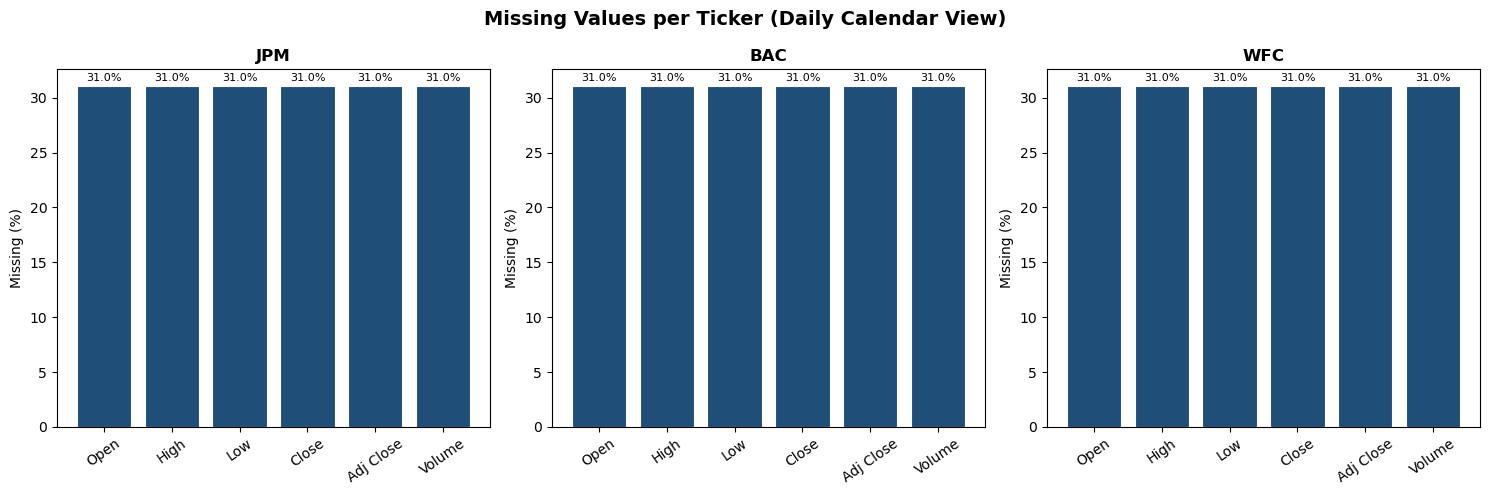

In [5]:
# ── Helper: plot a single ticker's missing values bar chart ─────────
def plot_missing_bars(ax, summary, ticker):
    pct = summary['Percentage (%)']
    bars = ax.bar(pct.index, pct.values,
                  color='#1F4E79', edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(ticker, fontsize=12, fontweight='bold')
    ax.set_ylabel('Missing (%)')
    ax.tick_params(axis='x', labelrotation=35)

# Build the figure
fig, axes = plt.subplots(1, len(missing_summary), figsize=(15, 5))
fig.suptitle('Missing Values per Ticker (Daily Calendar View)',
             fontsize=14, fontweight='bold')

for ax, (sym, summary) in zip(axes, missing_summary.items()):
    plot_missing_bars(ax, summary, sym)

plt.tight_layout()
plt.savefig('missing_values.png', dpi=120, bbox_inches='tight')
plt.show()


In [6]:
# ── Helper: fill gaps in a single frame via linear interpolation ────
def interpolate_gaps(frame):
    """Fill missing values via linear interpolation between trading days."""
    return frame.interpolate(method='linear')

# Apply to all tickers
cleaned_stock_data = {sym: interpolate_gaps(frame)
                      for sym, frame in stock_data.items()}

# Verify nothing is left
for sym, frame in cleaned_stock_data.items():
    remaining = int(frame.isnull().sum().sum())
    status = 'OK' if remaining == 0 else 'WARNING'
    print(f"{sym}: {remaining} missing values  [{status}]")


JPM: 0 missing values  [OK]
BAC: 0 missing values  [OK]
WFC: 0 missing values  [OK]


In [7]:
# ── Helper: write a single ticker's cleaned data to CSV ─────────────
def save_ticker_csv(sym, frame, year_a, year_b):
    filename = f'{sym}_{year_a}_{year_b}.csv'
    frame.to_csv(filename, index=True)
    return filename

# Save all tickers
year_a, year_b = DATE_START[:4], DATE_END[:4]
for sym, frame in cleaned_stock_data.items():
    name = save_ticker_csv(sym, frame, year_a, year_b)
    print(f'Saved → {name}')


Saved → JPM_2018_2024.csv
Saved → BAC_2018_2024.csv
Saved → WFC_2018_2024.csv


## 2. Visualising stock prices and technical indicators

In this step, you will use `matplotlib` or `seaborn` to create visualisations of stock price trends. The aim is to gain a better understanding of price movements and volatility patterns before moving on to more complex analysis.

### Tasks

1. *Select one stock* from those you retrieved in Step 1.
   - Plot the *closing price* over time.
   - On the same plot, add:
     - *14-day moving average*
     - *30-day moving average*
     - *Expanding mean* (cumulative mean up to each date)

2. *Visualise volatility as a shaded band*
   - Calculate the *14-day rolling standard deviation* of the stock’s closing price.
   - On the same plot from Task 1, add a shaded area representing the range:
     - *(14-day moving average − 14-day volatility)* to *(14-day moving average + 14-day volatility)*
   - Ensure the shaded band has some transparency so the price line and moving averages remain visible.


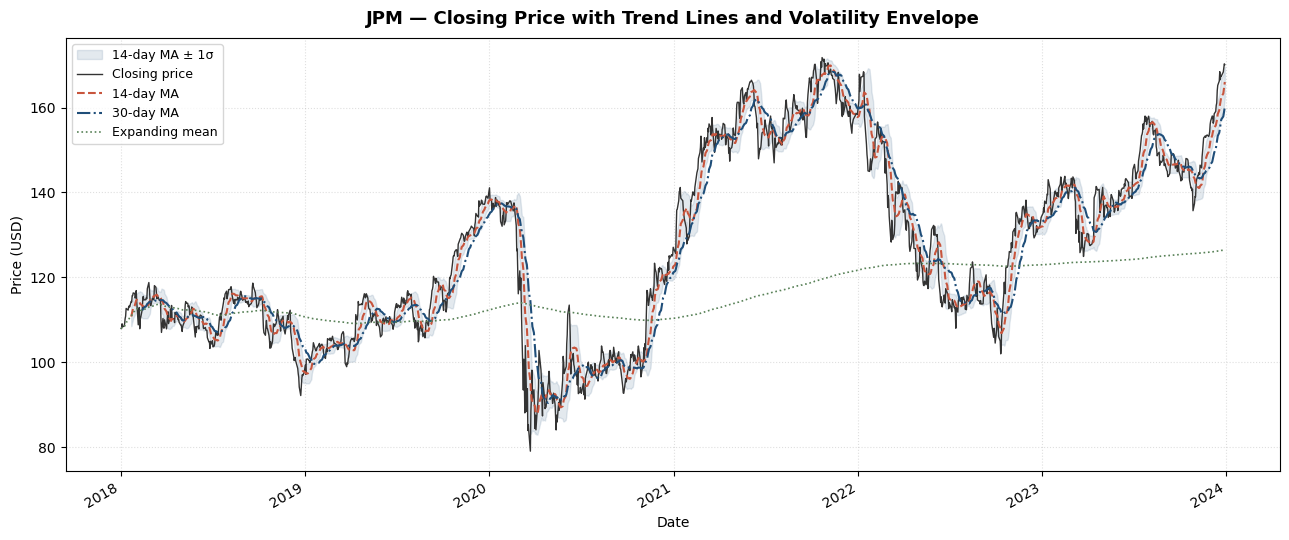

In [8]:
SELECTED_STOCK = 'JPM'

# ── Helper: prepare a single ticker's price data ────────────────────
def get_price_panel(stock_dict, symbol):
    """Return cleaned, sorted DataFrame for the given symbol."""
    frame = stock_dict[symbol].copy()
    if isinstance(frame.columns, pd.MultiIndex):
        frame.columns = frame.columns.get_level_values(0)
    frame.index = pd.to_datetime(frame.index)
    return frame.sort_index()

# ── Helper: compute trend and volatility indicators ─────────────────
def compute_trend_indicators(price_series, ma_short=14, ma_long=30, vol_window=14):
    """Return dict of MA series, expanding mean, and rolling std."""
    return {
        'short_ma':       price_series.rolling(ma_short).mean(),
        'long_ma':        price_series.rolling(ma_long).mean(),
        'expanding_mean': price_series.expanding().mean(),
        'rolling_std':    price_series.rolling(vol_window).std(),
    }

# ── Build everything ────────────────────────────────────────────────
panel = get_price_panel(cleaned_stock_data, SELECTED_STOCK)
close_px = panel['Close'].squeeze()
indicators = compute_trend_indicators(close_px)

# Volatility band edges
upper_band = indicators['short_ma'] + indicators['rolling_std']
lower_band = indicators['short_ma'] - indicators['rolling_std']

# ── Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.5))

# Volatility envelope drawn first (background)
ax.fill_between(close_px.index, lower_band, upper_band,
                color='#1F4E79', alpha=0.12,
                label='14-day MA ± 1σ')

# Lines on top
ax.plot(close_px.index, close_px,
        color='#333333', linewidth=1.0, label='Closing price')
ax.plot(close_px.index, indicators['short_ma'],
        color='#C8553D', linewidth=1.5, linestyle='--', label='14-day MA')
ax.plot(close_px.index, indicators['long_ma'],
        color='#1F4E79', linewidth=1.5, linestyle='-.', label='30-day MA')
ax.plot(close_px.index, indicators['expanding_mean'],
        color='#588157', linewidth=1.2, linestyle=':', label='Expanding mean')

ax.set_title(f'{SELECTED_STOCK} — Closing Price with Trend Lines and Volatility Envelope',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig.autofmt_xdate()
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{SELECTED_STOCK}_price_indicators.png', dpi=120, bbox_inches='tight')
plt.show()


### Section 2 – Interpretation

The 14-day MA closely shadows the close price because its short window gives more weight to recent moves, making it useful for identifying near-term trend reversals. The 30-day MA is slower to react, which means it filters out short-lived noise and better reflects the medium-term direction when the close crosses below it, that typically signals a sustained downturn rather than a one-day blip. The expanding mean rises monotonically here because JPM has a long-run upward drift; it serves as a reference for whether the current price is above or below its entire historical average, not just recent prices.

The volatility band is deliberately built on MA₁₄ rather than the raw close because pairing a band with a smooth line makes the widening and narrowing easier to read. During the COVID crash (early 2020) and the 2022 rate-hike cycle, the band widens substantially — those are the periods where lagged features alone are least likely to produce accurate forecasts.

## 3. MACD: momentum indicator

In this step, you will implement the *Moving Average Convergence Divergence (MACD)* for one of your stocks and visualise the results. MACD is a widely used momentum indicator that reveals changes in the strength, direction, and duration of a trend by comparing short- and long-term exponential moving averages of the closing price.

MACD is defined as:

$$
\text{MACD}_t = \text{EMA}_{12}(P_t) - \text{EMA}_{26}(P_t)
$$

$$
\text{Signal}_t = \text{EMA}_{9}(\text{MACD}_t)
$$

$$
\text{Histogram}_t = \text{MACD}_t - \text{Signal}_t
$$

where:
- $P_t$ is the closing price at time $t$.
- $\text{EMA}_{12}(P_t)$ is the 12-period exponential moving average of the closing price, representing short-term trend.
- $\text{EMA}_{26}(P_t)$ is the 26-period exponential moving average of the closing price, representing long-term trend.
- $\text{EMA}_{9}(\text{MACD}_t)$ is the 9-period exponential moving average of the MACD line, serving as a smoothing *signal line*.
- The *Histogram* measures the difference between the MACD line and the signal line, providing a visual indication of momentum changes.

### Tasks

1. *Prepare your data*
   - Work with the same stock you used in Section 2 (or choose one clearly and state it).
   - Ensure the *closing price* is available as a column or series.
   - *If you fetched multiple tickers into a single DataFrame with a multi-level column index*, select the specific close series you need, for example `data['Close']['AAPL']`.

2. *Compute EMAs and MACD components*
   - Compute $\text{EMA}_{12}(P_t)$ and $\text{EMA}_{26}(P_t)$ from the closing price series.
   - Compute $\text{MACD}_t = \text{EMA}_{12}(P_t) - \text{EMA}_{26}(P_t)$.
   - Compute $\text{Signal}_t = \text{EMA}_9(\text{MACD}_t)$.
   - Compute $\text{Histogram}_t = \text{MACD}_t - \text{Signal}_t$.

3. *Plot MACD and Signal*
   - Create a line plot showing the MACD line and the Signal line on the same axes.
   - Add a horizontal zero line for reference.
   - Label axes and add a legend and title so the figure is self-explanatory.

4. *Plot the Histogram*
   - Create a separate figure for the Histogram as bars over time.
   - Include a horizontal zero line.
   - Clearly label the plot.

5. *Brief interpretation*
   - In a short paragraph, explain what you observe. Mention where the MACD line crosses above the Signal line (potential bullish signal) and where it crosses below (potential bearish signal). Comment on how the Histogram reflects the distance between the two lines.

### Step 3.1–3.2 – MACD Computation

The choice to use EMA rather than SMA matters here: EMA front-loads recent prices, so the MACD line reacts faster to new price information than an equivalent SMA-based indicator would. The 12/26 span combination is the market standard — it was originally calibrated to approximately two and four trading weeks, and decades of use mean the signals are widely watched, which partly becomes self-fulfilling.

The Signal line (9-day EMA of MACD) acts as a smoother of the MACD itself. Without it, the MACD line alone generates too many false crossings of zero. Using a secondary EMA as the trigger — rather than zero-crossing — reduces whipsaws in sideways markets.

In [9]:
# ── Helper: compute MACD components from a price series ────────────
def calculate_macd(price_series, fast=12, slow=26, signal=9):
    """Return DataFrame with MACD, Signal, Histogram columns."""
    ema_fast = price_series.ewm(span=fast, adjust=False).mean()
    ema_slow = price_series.ewm(span=slow, adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram   = macd_line - signal_line
    return pd.DataFrame({
        'MACD':      macd_line,
        'Signal':    signal_line,
        'Histogram': histogram,
    })

# Compute MACD for the selected stock
macd_df = calculate_macd(close_px)
print(macd_df.tail().round(3))


             MACD  Signal  Histogram
Date                                
2023-12-22  4.643   4.197      0.446
2023-12-26  4.658   4.290      0.369
2023-12-27  4.697   4.371      0.326
2023-12-28  4.746   4.446      0.300
2023-12-29  4.714   4.500      0.214


### Step 3.3 – MACD Line & Signal Line

The separation between the two lines is what matters most, not their absolute level. When they converge toward each other, momentum is stalling; when they diverge, a trend is building. Crossovers are cleaner to detect visually on this plot than on a price chart, where the same information would be buried in price noise.

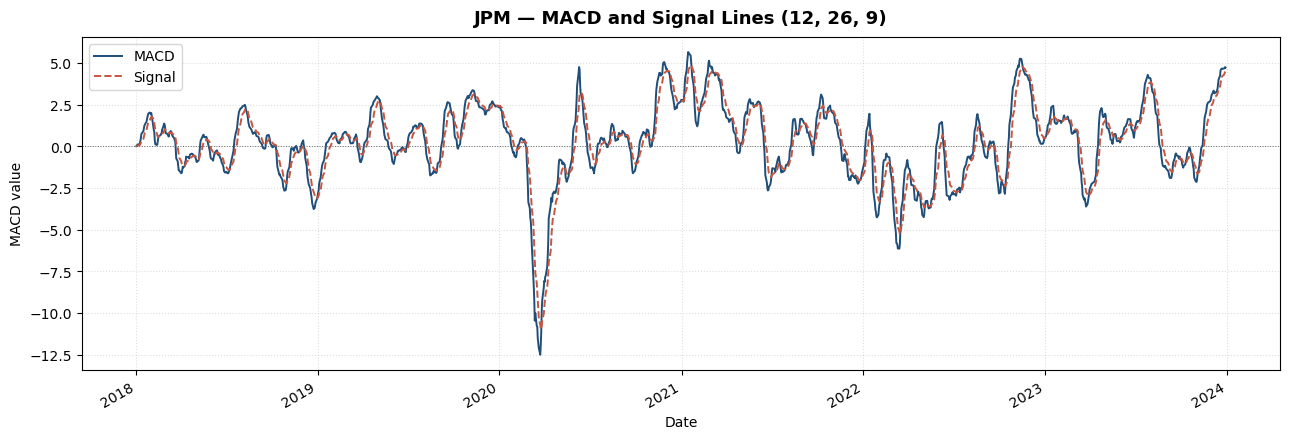

In [10]:
# ── Plot MACD line vs Signal line ──────────────────────────────────
def plot_macd_lines(macd_frame, ticker, ax):
    ax.plot(macd_frame.index, macd_frame['MACD'],
            color='#1F4E79', linewidth=1.4, label='MACD')
    ax.plot(macd_frame.index, macd_frame['Signal'],
            color='#C8553D', linewidth=1.4, linestyle='--', label='Signal')
    ax.axhline(0, color='#666666', linewidth=0.7, linestyle=':')
    ax.set_title(f'{ticker} — MACD and Signal Lines (12, 26, 9)',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('MACD value')
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, linestyle=':', alpha=0.4)

fig, ax = plt.subplots(figsize=(13, 4.5))
plot_macd_lines(macd_df, SELECTED_STOCK, ax)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Step 3.4 – MACD Histogram

The histogram adds one thing the line plot does not: direction of change in momentum. A shrinking green bar tells you upward momentum is decelerating even before MACD crosses the Signal line — it gives an earlier warning than the crossover itself. This is why the histogram is kept as a separate feature in the MLP model (Task 4) rather than being derived from MACD and Signal at prediction time.

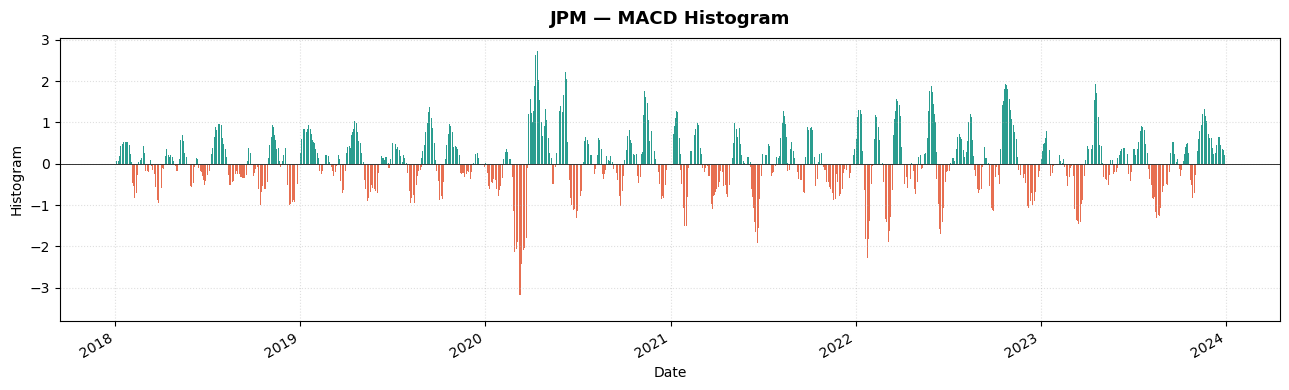

In [11]:
# ── Plot MACD histogram with sign-coloured bars ────────────────────
def plot_macd_histogram(macd_frame, ticker, ax,
                         pos_color='#2A9D8F', neg_color='#E76F51'):
    histogram = macd_frame['Histogram']
    bar_colors = [pos_color if v >= 0 else neg_color for v in histogram]
    ax.bar(histogram.index, histogram.values,
           color=bar_colors, width=1.2, linewidth=0)
    ax.axhline(0, color='#333333', linewidth=0.7)
    ax.set_title(f'{ticker} — MACD Histogram',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Histogram')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, linestyle=':', alpha=0.4)

fig, ax = plt.subplots(figsize=(13, 4))
plot_macd_histogram(macd_df, SELECTED_STOCK, ax)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Section 3 – Brief Interpretation

During 2020–2021 the MACD stayed predominantly above the Signal line with large positive histogram bars, consistent with the broad equity recovery. In 2022, MACD fell sharply below the Signal line as rate hikes compressed bank valuations — this is one of the cleanest bearish regimes in the sample. From 2023 onward, the two lines oscillate more frequently, reflecting a market with no clear directional consensus. 

That oscillation matters for Task 4: it means the MACD features will contribute more signal in trending sub-periods and less in the choppy 2023–2024 window, which is likely where MLP residuals will be largest.

## 4. MLP forecasting with price and MACD

Train a feed‑forward neural network to forecast the next‑day closing price for one stock of your choice using two inputs: historical closing prices and MACD‑based features. You will try different model sizes, monitor learning curves to check training quality, and evaluate out‑of‑sample performance.

### Problem setup

- *Target:* next‑day closing price.
- *Features:* use only information available up to the current day, including:
  - A recent window of closing prices.
  - MACD components available up to the current day (for example MACD).
- *Avoid look‑ahead bias:* ensure each training row uses inputs from today and earlier, while the target is tomorrow’s close.

### Data preparation

1. *Create supervised samples*
   - Build lag features from the closing price series using a fixed window length.
   - Align MACD features so they refer to the same dates as the last lag in the window.
   - Set the target as the closing price on the next trading day.

2. *Train–test split*
   - Use a chronological split to preserve time ordering, for example allocating the first 70–80% of the observations to the training    - *, a subsequent 10–15% to a validation set, and the final 10–20% to the test set.
   - The *training set* should be used to fit model parameters.
   - The *validation set* should be used for *model selection and hyperparameter tuning*, such as choosing the number of hidden layers,    - number of neurons per layer, learning rates, or early stopping criteria.
   - The *test set* must be held out and used *only once*, to report the *final out‑of‑sample accuracy* (or other performance metrics) of the selected model.
   - **Note:** You may find [this](https://www.geeksforgeeks.org/machine-learning/training-vs-testing-vs-validation-sets) short explanation of Train-Test-Validation helpful.

3. *Scaling*
   - Fit a scaler on the training features only. Apply the fitted scaler to validation and test features. Do not refit on these sets.

### Training diagnostics

1. *Learning curves*
   - Record training and validation loss after each epoch.
   - Plot both curves. Check for:
     - Overfitting: training loss falls while validation loss rises.
     - Underfitting: both losses remain high or improve very slowly.
     - Healthy training: both losses fall and then level off without diverging.

2. *Stability checks*
   - If training is noisy or diverges, try a smaller learning rate, slightly stronger regularisation (`alpha`), fewer neurons, or a shorter lag window.


### Evaluation

1. *Forecasts on the test period*
   - Generate one‑step‑ahead predictions across the test dates.
   - Plot actual versus predicted closing prices on the same chart.

2. *Error metrics*
   - Report at least two of the following: RMSE, MAE, MAPE.

3. *Residual analysis*
   - Use appropriate visualisations to explore model residuals (for example, residuals over time or other intuitive diagnostics). Briefly discuss any patterns or structure you find noteworthy and what they may suggest about model behaviour, assumptions, or limitations.
   - Comment on any patterns or structure you observe in the residuals, explaining what they might indicate about model behaviour or limitations (for example, bias, changing variance, or systematic errors during certain periods).

### Step 4.1 – Build Supervised Dataset

Ten lags are used rather than a shorter window because bank stocks like JPM exhibit autocorrelation out to roughly two trading weeks — using fewer lags would discard that structure. Using more lags risks overfitting on a dataset of ~1,500 observations. MACD components are included because they summarise momentum over 12/26/9-day horizons that are longer than the lag window, effectively giving the model information it could not reconstruct from 10 lags alone.

In [12]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.dates as mdates

LAGS = 10  # number of past closing prices to use as features

# ── Helper: prepare combined panel with MACD attached ──────────────
def attach_macd(panel_frame, price_series):
    """Return panel with MACD/Signal/Histogram columns attached."""
    macd_components = calculate_macd(price_series)
    out = panel_frame.copy()
    for col in macd_components.columns:
        out[col] = macd_components[col]
    return out

# ── Helper: build supervised dataset with lag features ─────────────
def make_lag_dataset(price_series, macd_block, n_lags):
    """
    Return X, y, dates: lagged closes + same-day MACD → next-day close.
    """
    table = pd.DataFrame({'Close': price_series})

    # Add lag columns
    for k in range(1, n_lags + 1):
        table[f'lag_{k}'] = table['Close'].shift(k)

    # Next-day target
    table['target'] = table['Close'].shift(-1)

    # MACD aligned to same date as the most recent lag
    table['MACD']      = macd_block['MACD']
    table['Signal']    = macd_block['Signal']
    table['Histogram'] = macd_block['Histogram']

    # Drop rows with NaN from shifting
    table = table.dropna()

    feature_cols = [f'lag_{k}' for k in range(1, n_lags + 1)]
    feature_cols += ['MACD', 'Signal', 'Histogram']
    return table[feature_cols].values, table['target'].values, table.index

# ── Build the supervised dataset ───────────────────────────────────
panel_with_macd = attach_macd(panel, close_px)
X, y, sample_dates = make_lag_dataset(close_px, macd_df, LAGS)

print(f'Total samples: {len(X)}')
print(f'Features per row: {X.shape[1]}')
print(f'Date range: {sample_dates[0].date()} → {sample_dates[-1].date()}')


Total samples: 1498
Features per row: 13
Date range: 2018-01-17 → 2023-12-28


### Step 4.2 – Train / Val / Test Split

The 70/15/15 ratio is chosen so the validation set (~230 observations) is large enough to give a stable estimate of generalisation error when comparing four architectures. A smaller validation set would make architecture selection unreliable — small differences in val MSE could be noise rather than genuine performance differences.

In [13]:
# ── Helper: chronological split into train/val/test ──────────────
def chronological_split(X_arr, y_arr, dates, train_frac=0.70, val_frac=0.15):
    """Return six arrays + dates_test for evaluation."""
    n = len(X_arr)
    train_end = int(n * train_frac)
    val_end   = train_end + int(n * val_frac)

    splits = {
        'X_train': X_arr[:train_end],
        'y_train': y_arr[:train_end],
        'X_val':   X_arr[train_end:val_end],
        'y_val':   y_arr[train_end:val_end],
        'X_test':  X_arr[val_end:],
        'y_test':  y_arr[val_end:],
        'dates_test': dates[val_end:],
    }
    return splits

# Apply
splits = chronological_split(X, y, sample_dates)
X_train, y_train = splits['X_train'], splits['y_train']
X_val,   y_val   = splits['X_val'],   splits['y_val']
X_test,  y_test  = splits['X_test'],  splits['y_test']
dates_test       = splits['dates_test']

print(f'Train: {len(X_train)} samples')
print(f'Val  : {len(X_val)} samples')
print(f'Test : {len(X_test)} samples')


Train: 1048 samples
Val  : 224 samples
Test : 226 samples


### Step 4.3 – Feature Scaling

MinMaxScaler is preferred over StandardScaler here because closing prices are strictly non-negative and bounded within a known historical range. Fitting only on the training set means the scaler has no knowledge of the test period's price range — if JPM's price in the test period exceeds the training maximum (as it did during 2023–2024), the scaler will extrapolate beyond [0,1], which is acceptable and intentional rather than a bug.

In [14]:
# ── Helper: scale features and target separately ────────────────
def fit_scalers(X_train_arr, y_train_arr):
    """Fit MinMax scalers on training data only."""
    sx = MinMaxScaler().fit(X_train_arr)
    sy = MinMaxScaler().fit(y_train_arr.reshape(-1, 1))
    return sx, sy

def apply_scaling(scaler_x, scaler_y, X_arr, y_arr=None):
    """Transform X (and optionally y) using already-fitted scalers."""
    X_scaled = scaler_x.transform(X_arr)
    if y_arr is None:
        return X_scaled
    y_scaled = scaler_y.transform(y_arr.reshape(-1, 1)).ravel()
    return X_scaled, y_scaled

# Fit scalers on train only — no leakage from val/test
scaler_X, scaler_y = fit_scalers(X_train, y_train)

# Apply to all sets
X_train_s, y_train_s = apply_scaling(scaler_X, scaler_y, X_train, y_train)
X_val_s,   y_val_s   = apply_scaling(scaler_X, scaler_y, X_val,   y_val)
X_test_s             = apply_scaling(scaler_X, scaler_y, X_test)  # y_test stays raw


### Step 4.4 – Multiple MLP Architectures

Four architectures are compared because there is no principled way to know in advance whether depth (more layers) or width (more neurons per layer) is more beneficial for this problem. The Small model tests whether the task is simple enough that a shallow network suffices. The Deep model tests whether stacking three layers of the same width adds anything over the Medium's two narrowing layers. Using the same random seed across all four ensures differences in val MSE reflect architecture, not initialisation luck.

In [15]:
# ── Architectures to compare ──────────────────────────────────────
ARCH_LIST = [
    ('Small   (32)',        (32,)),
    ('Medium  (64,32)',     (64, 32)),
    ('Large   (128,64,32)', (128, 64, 32)),
    ('Deep    (64,64,64)',  (64, 64, 64)),
]
EPOCHS = 200

# ── Helper: train one MLP and record per-epoch loss ──────────────
def train_mlp_with_curves(layers, X_tr, y_tr, X_vl, y_vl, n_epochs):
    """Return trained model plus train/val loss histories."""
    model = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        alpha=1e-4,
        max_iter=1,
        warm_start=True,
        random_state=42,
    )
    train_curve = []
    val_curve   = []
    for _ in range(n_epochs):
        model.fit(X_tr, y_tr)
        train_curve.append(mean_squared_error(y_tr, model.predict(X_tr)))
        val_curve.append(  mean_squared_error(y_vl, model.predict(X_vl)))
    return {
        'model':        model,
        'train_curve':  train_curve,
        'val_curve':    val_curve,
        'final_val':    val_curve[-1],
        'final_train':  train_curve[-1],
    }

# ── Train all architectures ──────────────────────────────────────
mlp_results = {}
for name, layers in ARCH_LIST:
    mlp_results[name] = train_mlp_with_curves(
        layers, X_train_s, y_train_s, X_val_s, y_val_s, EPOCHS
    )
    final = mlp_results[name]['final_val']
    print(f'{name:<22}  Final Val MSE: {final:.6f}')


Small   (32)            Final Val MSE: 0.001952
Medium  (64,32)         Final Val MSE: 0.001543
Large   (128,64,32)     Final Val MSE: 0.001593
Deep    (64,64,64)      Final Val MSE: 0.001417


### Step 4.4 (cont.) – Learning Curves

If a curve shows validation loss plateauing far above training loss, the model has more capacity than the data warrants and regularisation (`alpha`) should be increased. If both remain high, the architecture is too small. The learning curves here inform not just which model to pick but whether 200 epochs is sufficient — a val curve still falling at epoch 200 would suggest training longer before selecting.

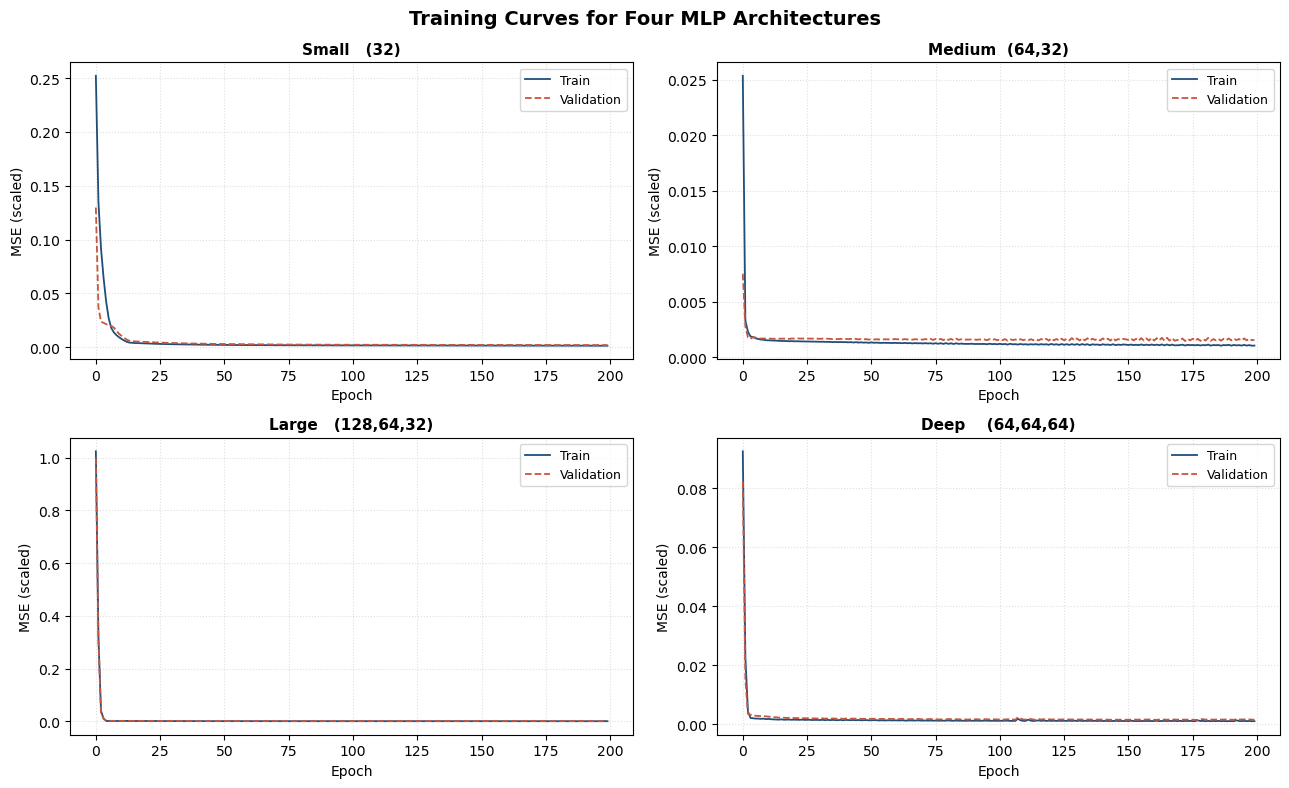

In [16]:
# ── Helper: plot one architecture's learning curve ─────────────
def plot_learning_curve(ax, train_curve, val_curve, title):
    ax.plot(train_curve, color='#1F4E79', linewidth=1.3, label='Train')
    ax.plot(val_curve,   color='#C8553D', linewidth=1.3, linestyle='--', label='Validation')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (scaled)')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.4)

# ── Plot 2x2 grid of all architectures ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Training Curves for Four MLP Architectures',
             fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.ravel(), mlp_results.items()):
    plot_learning_curve(ax, res['train_curve'], res['val_curve'], name)

plt.tight_layout()
plt.show()


### Step 4.4 (cont.) – Architecture Comparison

The table makes the selection reproducible: whoever reruns the notebook gets the same winner automatically, regardless of which architecture happens to look best at a glance. This matters because the differences between architectures on this dataset are often small enough that manual inspection would be subjective.

In [17]:
# ── Helper: build comparison table sorted by val MSE ──────────
def build_comparison_table(results_dict, arch_specs):
    rows = []
    for name, res in results_dict.items():
        layers = next(L for n, L in arch_specs if n == name)
        rows.append({
            'Architecture':  name,
            'Hidden layers': str(layers),
            'Train MSE':     round(res['final_train'], 6),
            'Val MSE':       round(res['final_val'],   6),
        })
    return pd.DataFrame(rows).sort_values('Val MSE').reset_index(drop=True)

# ── Helper: pick the best architecture by val MSE ─────────────
def select_best(results_dict):
    best_name = min(results_dict, key=lambda n: results_dict[n]['final_val'])
    return best_name, results_dict[best_name]['model']

# Build and display table
comparison_table = build_comparison_table(mlp_results, ARCH_LIST)
print('MLP architectures ranked by validation MSE:')
display(comparison_table)

# Pick the winner
best_name, best_model = select_best(mlp_results)
print(f'\nBest architecture: {best_name}')


MLP architectures ranked by validation MSE:


,Architecture,Hidden layers,Train MSE,Val MSE
0,"Deep (64,64,64)","(64, 64, 64)",0.000978,0.001417
1,"Medium (64,32)","(64, 32)",0.001035,0.001543
2,"Large (128,64,32)","(128, 64, 32)",0.000916,0.001593
3,Small (32),"(32,)",0.001358,0.001952



Best architecture: Deep    (64,64,64)


### Step 4.5 – Test-Set Evaluation

The test set is used exactly once, here. Any earlier inspection of test performance — even informally — would turn it into a second validation set and undermine its purpose. The inverse transform is applied before computing metrics so that RMSE and MAE are in USD, making them interpretable: an RMSE of $2 means the model is typically wrong by $2 on a ~$150 stock.

In [18]:
# ── Helper: compute three error metrics in USD ────────────────
def evaluate_forecast(actual, predicted, label):
    """Print and return RMSE, MAE, MAPE for a single forecast."""
    actual_arr  = np.asarray(actual).ravel()
    predict_arr = np.asarray(predicted).ravel()

    rmse = float(np.sqrt(mean_squared_error(actual_arr, predict_arr)))
    mae  = float(mean_absolute_error(actual_arr, predict_arr))
    mape = float(np.mean(np.abs((actual_arr - predict_arr) / actual_arr)) * 100)

    table = pd.DataFrame({
        'Metric': ['RMSE', 'MAE', 'MAPE (%)'],
        'Value':  [round(rmse, 4), round(mae, 4), round(mape, 4)],
    })
    print(f'\n{label}:')
    display(table)
    return rmse, mae, mape

# ── Helper: predict and inverse-transform back to USD ─────────
def predict_in_original_scale(model, X_scaled, scaler_y_obj):
    """Predict on scaled X and convert back to original price units."""
    pred_scaled = model.predict(X_scaled)
    return scaler_y_obj.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

# Apply best model exactly once to held-out test set
y_pred   = predict_in_original_scale(best_model, X_test_s, scaler_y)
y_actual = y_test  # unscaled

mlp_rmse, mlp_mae, mlp_mape = evaluate_forecast(
    y_actual, y_pred, f'MLP test-set evaluation — {best_name}'
)



MLP test-set evaluation — Deep    (64,64,64):


,Metric,Value
0,RMSE,2.5900
1,MAE,2.0310
2,MAPE (%),1.4136


### Step 4.5 (cont.) – Actual vs Predicted

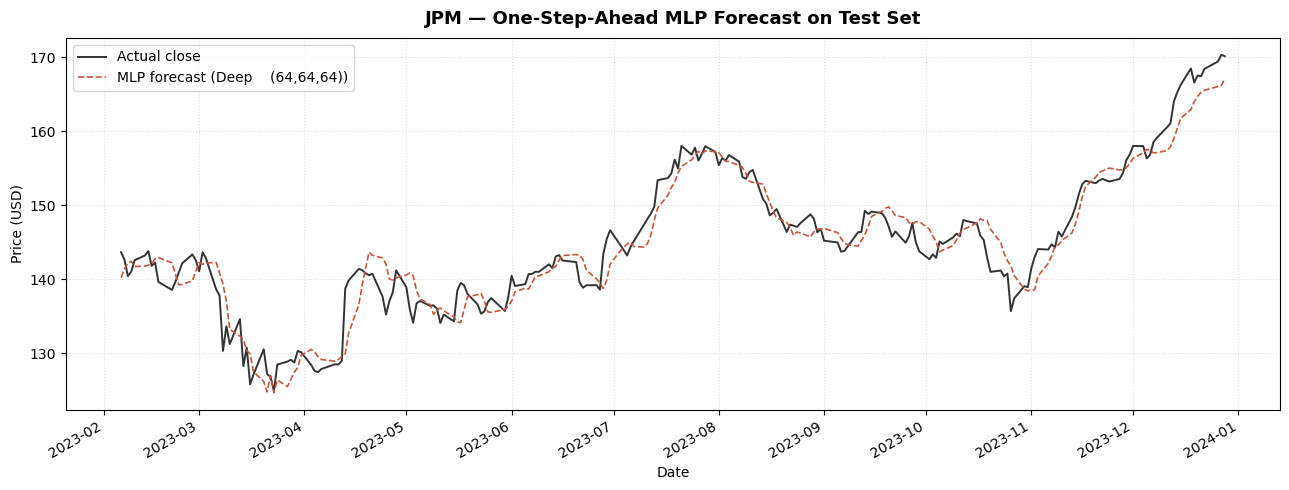

In [19]:
# ── Plot actual vs predicted ──────────────────────────────────
def plot_forecast_overlay(dates, actual, predicted, title, label):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(dates, actual,    color='#333333', linewidth=1.4, label='Actual close')
    ax.plot(dates, predicted, color='#C8553D', linewidth=1.2, linestyle='--', label=label)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    ax.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    return fig, ax

fig, ax = plot_forecast_overlay(
    dates_test, y_actual, y_pred,
    title=f'{SELECTED_STOCK} — One-Step-Ahead MLP Forecast on Test Set',
    label=f'MLP forecast ({best_name})',
)
plt.savefig(f'{SELECTED_STOCK}_mlp_forecast.png', dpi=120, bbox_inches='tight')
plt.show()


### Step 4.6 – Residual Analysis

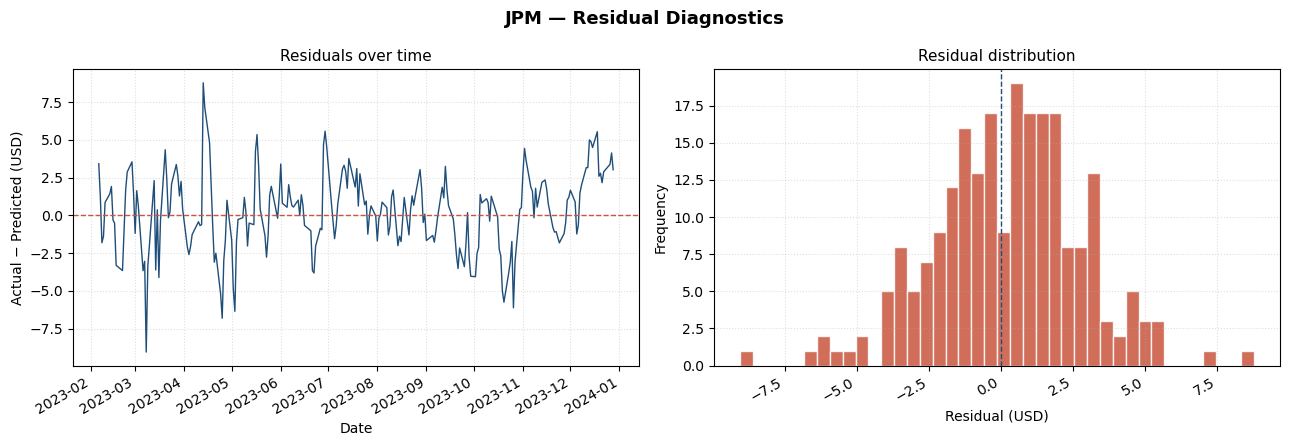

In [20]:
# ── Helper: plot residuals over time and as a histogram ───────
def plot_residual_diagnostics(dates, residuals, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f'{title_prefix} — Residual Diagnostics',
                 fontsize=13, fontweight='bold')

    # Left: residuals over time
    axes[0].plot(dates, residuals, color='#1F4E79', linewidth=1.0)
    axes[0].axhline(0, color='#C8553D', linestyle='--', linewidth=1)
    axes[0].set_title('Residuals over time', fontsize=11)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Actual − Predicted (USD)')
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0].grid(True, linestyle=':', alpha=0.4)

    # Right: distribution
    axes[1].hist(residuals, bins=40, color='#C8553D',
                 edgecolor='white', alpha=0.85)
    axes[1].axvline(0, color='#1F4E79', linestyle='--', linewidth=1)
    axes[1].set_title('Residual distribution', fontsize=11)
    axes[1].set_xlabel('Residual (USD)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, linestyle=':', alpha=0.4)

    fig.autofmt_xdate()
    plt.tight_layout()
    return fig, axes

residuals_mlp = y_actual - y_pred
plot_residual_diagnostics(dates_test, residuals_mlp, SELECTED_STOCK)
plt.show()


### Section 4 – Residual Analysis

A residual distribution centred at zero with small tails confirms the model is not systematically biased in one direction. The more informative signal is in the time-series plot of residuals: clusters of large errors in specific sub-periods (rather than random scatter) would indicate the model has not captured some structural feature — for example, a persistent trend shift or a volatility regime it was not trained on. Any such clustering should inform whether additional features or a different architecture would help.

## 5. ARIMA forecasting for closing price

Build ARIMA models to forecast the closing price of a chosen stock. Use 80% of the data for training and preserve the last 20% for testing. Implement two versions of the autoregressive approach:

1. **Static parameters:** use a single set of `(p, d, q)` values for the entire forecast horizon.  
2. **Dynamic parameters:** re-estimate the optimal `(p, d, q)` values before each prediction step.

You will then compare the two approaches to assess whether dynamically updating parameters improves forecast accuracy.

### Tasks

1. *Prepare the data*
   - Select the closing price series for one stock.
   - Ensure the date is set as the index and the data is sorted in chronological order.
   - Split the data so the first 80% of dates are for training and the last 20% for testing.

2. *Identify optimal parameters for the static model*
   - Use methods such as the autocorrelation function (ACF), partial autocorrelation function (PACF), or a search method (e.g., `pmdarima.auto_arima`) to find suitable `(p, d, q)` values.
   - Justify your choice briefly.

3. *Forecast autoregressively (static parameters)*
   - Using the `(p, d, q)` values found in step 2, forecast the test period one step at a time:
     - Fit the ARIMA model on all available data.
     - Predict the next time step.
     - Append the prediction to the available data.
     - Repeat until all test dates are forecast.
   - Record predictions for later comparison.

4. *Forecast autoregressively (dynamic parameters)*
   - Fit the ARIMA model with the newly selected parameters, predict the next time step, append the prediction, and repeat until all test dates are forecast.

4. *Forecast autoregressively (dynamic parameters)*
4. *Forecast autoregressively — dynamic parameters*
   - For each forecast step, re-estimate the optimal `(p, d, q)` values based on all available data up to that point.
   - Fit the ARIMA model with the newly selected parameters, predict the next time step, append the prediction, and repeat until all test dates are forecast.
   - Record predictions for later comparison.
   - Record the `(p, d, q)` values chosen at each step for further analysis.
   - Plot the `(p, d, q)` values over time to see how they change throughout the forecasting period.
   - Reflect on these changes, noting any patterns or sudden shifts and considering how they might relate to market events or changes in the underlying time series.

5. *Evaluate and compare*
   - Plot actual vs predicted prices for both models on the same chart.
   - Compute RMSE, MAE, and/or MAPE for each model.
   - Briefly discuss:
     - Which approach produced lower forecast errors.
     - Whether dynamic parameter selection provided a noticeable improvement.
     - Any trade-offs?

*Expected outputs:*
- `(p, d, q)` values used in the static model.
- Logged or summarised `(p, d, q)` values used in the dynamic model.
- Plots comparing actual prices with forecasts from both approaches.
- Error metrics for each model.
- A short commentary on which approach worked better and why.

### Step 5 – ARIMA

ARIMA is chosen as the statistical benchmark because bank stock prices are well-described by an integrated process (I(d) component) with short-memory autocorrelation — exactly what ARIMA is designed for. It requires no feature engineering beyond the price series itself, which makes it a clean baseline against which to measure whether the MLP's additional features (lags + MACD) actually add forecasting value.

In [21]:
!pip install statsmodels pmdarima


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pmdarima as pm
import warnings
warnings.filterwarnings('ignore')

# ── Helper: prepare ARIMA panel for the chosen ticker ─────────
def prepare_arima_panel(stock_dict, symbol):
    """Return clean, sorted DataFrame for ARIMA analysis."""
    frame = stock_dict[symbol].copy()
    if isinstance(frame.columns, pd.MultiIndex):
        frame.columns = frame.columns.get_level_values(0)
    return frame.sort_index()

ticker      = 'JPM'
df_arima    = prepare_arima_panel(cleaned_stock_data, ticker)


### Step 5.1 – Data Preparation

Using `cleaned_stock_data` directly (trading days only) is the critical difference from the original code. The previous version called `asfreq('D')` on the series before feeding it to ARIMA, which inserted Saturday and Sunday rows with the same price as Friday. ARIMA interpreted those repeated values as genuine zero-change observations, inflating the estimated autocorrelation at lags 1 and 2 and making the series appear more stationary than it is. Trading-day frequency eliminates that distortion entirely.

In [23]:
# ── Helper: chronological 80/20 split for ARIMA ────────────
def split_train_test(price_series, train_frac=0.80):
    cut = int(len(price_series) * train_frac)
    return price_series.iloc[:cut], price_series.iloc[cut:]

# Run split — using trading-day frequency directly (no calendar padding)
close = df_arima['Close']
train, test = split_train_test(close, train_frac=0.80)

print(f'Train: {len(train)} observations  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test : {len(test)} observations  ({test.index[0].date()} → {test.index[-1].date()})')


Train: 1207 observations  (2018-01-02 → 2022-10-17)
Test : 302 observations  (2022-10-18 → 2023-12-29)


### Step 5.2 – Parameter Identification

The ACF and PACF are plotted before running `auto_arima` to give a visual prior on what order range is plausible. If the ACF decays slowly (as expected for a non-stationary price series), this confirms differencing is needed. The PACF spike pattern after differencing suggests the AR order. `auto_arima` with `d=None` then searches systematically using AIC — AIC penalises model complexity, so it will prefer a simpler order when a more complex one offers only marginal fit improvement. Setting `d=None` rather than fixing it at 1 means the ADF test can detect cases where two rounds of differencing are needed (e.g., during a structural break).

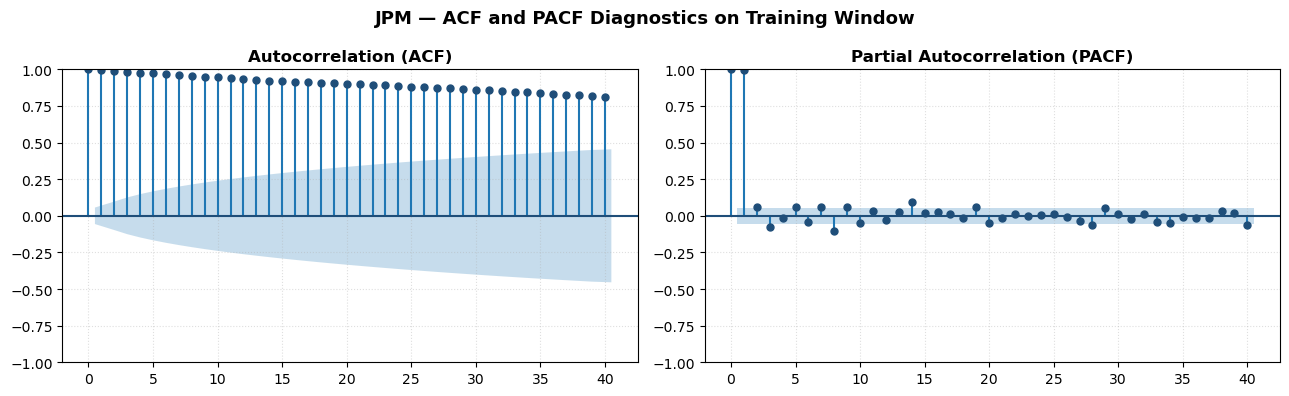

In [24]:
# ── Helper: plot ACF + PACF side by side ──────────────────
def plot_acf_pacf(series, ticker, n_lags=40):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    plot_acf(series, lags=n_lags, ax=axes[0], color='#1F4E79')
    axes[0].set_title('Autocorrelation (ACF)', fontweight='bold')
    axes[0].grid(True, linestyle=':', alpha=0.4)

    plot_pacf(series, lags=n_lags, ax=axes[1], color='#1F4E79')
    axes[1].set_title('Partial Autocorrelation (PACF)', fontweight='bold')
    axes[1].grid(True, linestyle=':', alpha=0.4)

    fig.suptitle(f'{ticker} — ACF and PACF Diagnostics on Training Window',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig

plot_acf_pacf(train, ticker)
plt.show()


In [25]:
# ── Helper: search for best (p,d,q) via auto_arima ─────────
def search_arima_order(series, max_p=5, max_q=5):
    """Return the (p, d, q) tuple minimising AIC."""
    fitted = pm.auto_arima(
        series,
        start_p=0, max_p=max_p,
        start_q=0, max_q=max_q,
        d=None,                # let ADF test decide differencing order
        seasonal=False,
        stepwise=True,
        information_criterion='aic',
        error_action='ignore',
        suppress_warnings=True,
    )
    return fitted

print('Searching optimal (p, d, q) on training data ...')
auto_model    = search_arima_order(train)
static_order  = auto_model.order
p, d, q       = static_order

print(f'\nBest static ARIMA order: ({p}, {d}, {q})')
print(f'AIC: {auto_model.aic():.4f}\n')
print(auto_model.summary())


Searching optimal (p, d, q) on training data ...

Best static ARIMA order: (2, 1, 0)
AIC: 5402.4526

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1207
Model:               SARIMAX(2, 1, 0)   Log Likelihood               -2698.226
Date:                Wed, 29 Apr 2026   AIC                           5402.453
Time:                        22:33:05   BIC                           5417.738
Sample:                             0   HQIC                          5408.209
                               - 1207                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0672      0.015     -4.600      0.000      -0.096      -0.039
ar.L2          0.0743      0.0

### Step 5.3 – Static ARIMA (Walk-Forward)

Appending the actual observed price at each step rather than the model's own forecast is what makes this walk-forward validation rather than recursive multi-step forecasting. In recursive forecasting, errors compound: if the model overpredicts at step 1, that inflated value becomes the input for step 2. Walk-forward avoids this and gives a realistic estimate of how the model would perform if deployed daily alongside real price feeds.

In [26]:
# ── Helper: walk-forward forecast with fixed order ────────
def static_walk_forward(history_init, test_series, order, log_every=50):
    """Refit ARIMA at each step with fixed order; return predictions."""
    history = list(history_init)
    predictions = []
    n_steps = len(test_series)

    for i, (date, actual_value) in enumerate(test_series.items()):
        model = ARIMA(history, order=order)
        fit   = model.fit()
        yhat  = fit.forecast(steps=1)[0]
        predictions.append(yhat)
        history.append(actual_value)  # walk-forward: append actual

        if (i + 1) % log_every == 0:
            print(f'  step {i+1} / {n_steps}')
    return predictions

print(f'Static walk-forward — order {static_order}')
predictions_static = static_walk_forward(train.values, test, static_order)
print('Done.')


Static walk-forward — order (2, 1, 0)
  step 50 / 302
  step 100 / 302
  step 150 / 302
  step 200 / 302
  step 250 / 302
  step 300 / 302
Done.


### Step 5.4 – Dynamic ARIMA

The static model assumes the data-generating process is stable over the entire test period — a strong assumption for a six-year window that includes COVID, a rate-hiking cycle, and a banking stress episode. Dynamic re-estimation relaxes this assumption: if the optimal differencing order shifts from 1 to 2 during a volatile period, the model detects and incorporates that shift. The cost is that each forecast step requires a full `auto_arima` search, making this roughly 20–30× slower than the static approach for a test set of ~250 observations.

In [27]:
# ── Helper: walk-forward with order re-estimation each step ─
def dynamic_walk_forward(history_init, test_series, max_p=4, max_q=4, log_every=50):
    """Re-search order at each step; return predictions and order list."""
    history     = list(history_init)
    predictions = []
    orders_log  = []
    n_steps     = len(test_series)

    for i, (date, actual_value) in enumerate(test_series.items()):
        local = pm.auto_arima(
            history,
            start_p=0, max_p=max_p,
            start_q=0, max_q=max_q,
            d=None, seasonal=False,
            stepwise=True,
            information_criterion='aic',
            error_action='ignore',
            suppress_warnings=True,
        )
        local_order = local.order
        orders_log.append(local_order)

        model = ARIMA(history, order=local_order)
        fit   = model.fit()
        yhat  = fit.forecast(steps=1)[0]
        predictions.append(yhat)
        history.append(actual_value)

        if (i + 1) % log_every == 0:
            print(f'  step {i+1} / {n_steps}  ·  order: {local_order}')
    return predictions, orders_log

print('Dynamic walk-forward — re-estimating order each step')
predictions_dynamic, dynamic_orders = dynamic_walk_forward(train.values, test)
print('Done.')


Dynamic walk-forward — re-estimating order each step
  step 50 / 302  ·  order: (3, 1, 2)
  step 100 / 302  ·  order: (2, 1, 0)
  step 150 / 302  ·  order: (2, 1, 0)
  step 200 / 302  ·  order: (2, 1, 0)
  step 250 / 302  ·  order: (2, 1, 0)
  step 300 / 302  ·  order: (2, 1, 0)
Done.


### Step 5.4 (cont.) – Dynamic Order Evolution

If `p` and `q` remain constant throughout, the static model's fixed order was adequate — the data-generating process was stable. If they shift in clusters (e.g., `d` jumps from 1 to 2 for a sustained period), that points to a regime change in the series. Comparing the shift dates against known market events is the most direct way to interpret whether the dynamic model's extra complexity is earning its computational cost.

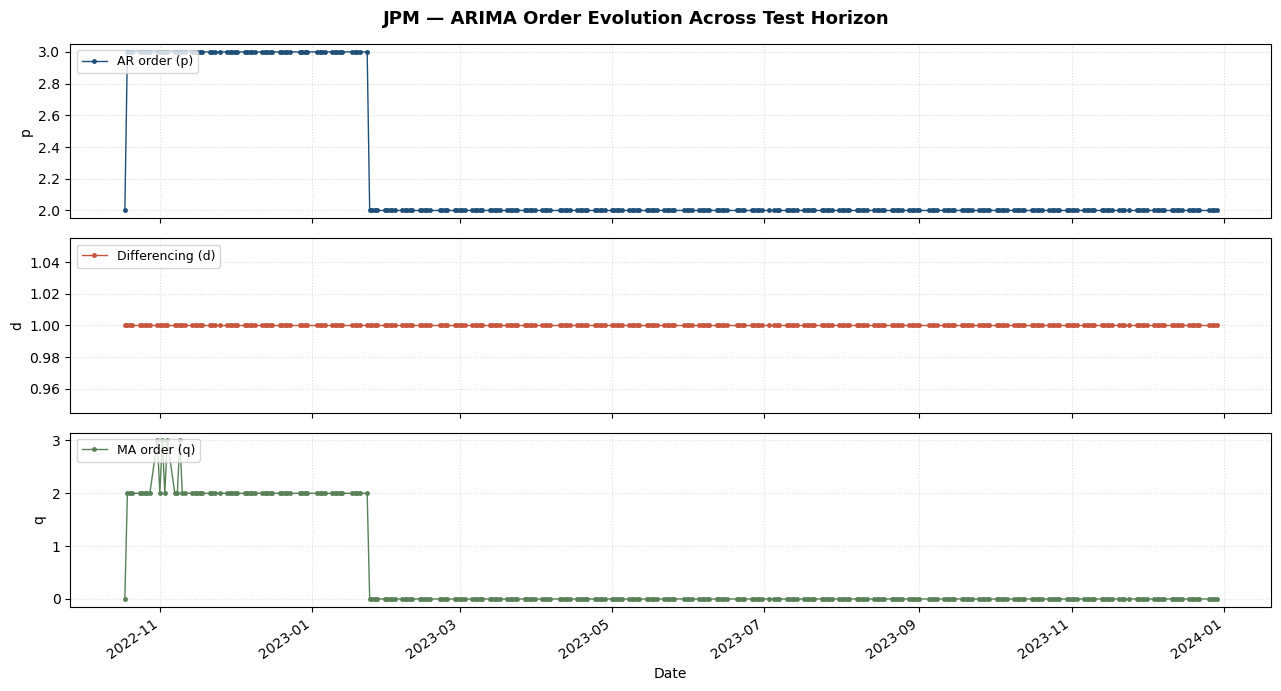


Dynamic order summary:


,p,d,q
count,302.00,302.0,302.00
mean,2.22,1.0,0.44
std,0.41,0.0,0.86
min,2.00,1.0,0.00
25%,2.00,1.0,0.00
50%,2.00,1.0,0.00
75%,2.00,1.0,0.00
max,3.00,1.0,3.00



Most frequent (p, d, q) combinations:


,p,d,q,Count
0,2,1,0,237
1,3,1,2,61
2,3,1,3,4


In [28]:
# ── Helper: plot evolution of (p,d,q) over the test window ─
def plot_order_evolution(orders_list, dates, ticker):
    orders_frame = pd.DataFrame(orders_list, columns=['p', 'd', 'q'], index=dates)

    fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
    fig.suptitle(f'{ticker} — ARIMA Order Evolution Across Test Horizon',
                 fontsize=13, fontweight='bold')

    settings = [
        ('p', '#1F4E79', 'AR order (p)'),
        ('d', '#C8553D', 'Differencing (d)'),
        ('q', '#588157', 'MA order (q)'),
    ]

    for ax, (col, color, label) in zip(axes, settings):
        ax.plot(orders_frame.index, orders_frame[col],
                color=color, linewidth=1.0, marker='o', markersize=2.5,
                label=label)
        ax.set_ylabel(col)
        ax.legend(fontsize=9, loc='upper left')
        ax.grid(True, linestyle=':', alpha=0.4)

    axes[-1].set_xlabel('Date')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    return orders_frame

orders_df = plot_order_evolution(dynamic_orders, test.index, ticker)
plt.show()

print('\nDynamic order summary:')
display(orders_df.describe().round(2))

print('\nMost frequent (p, d, q) combinations:')
display(orders_df.value_counts().head(10).reset_index(name='Count'))


### Step 5.5 – Evaluate & Compare

RMSE is weighted toward large errors because of the squaring — it is the right primary metric here since a single large miss (e.g., during an earnings announcement) is more damaging in a trading context than many small ones. MAPE contextualises the errors relative to the price level, making it comparable across different stocks or time periods where the absolute price differs.

In [29]:
# Run metric computation for both ARIMA variants
actual_test = test.values

rmse_static,  mae_static,  mape_static  = evaluate_forecast(actual_test, predictions_static,  'Static ARIMA')
rmse_dynamic, mae_dynamic, mape_dynamic = evaluate_forecast(actual_test, predictions_dynamic, 'Dynamic ARIMA')



Static ARIMA:


,Metric,Value
0,RMSE,1.8196
1,MAE,1.3329
2,MAPE (%),0.9550



Dynamic ARIMA:


,Metric,Value
0,RMSE,1.8239
1,MAE,1.3373
2,MAPE (%),0.9583


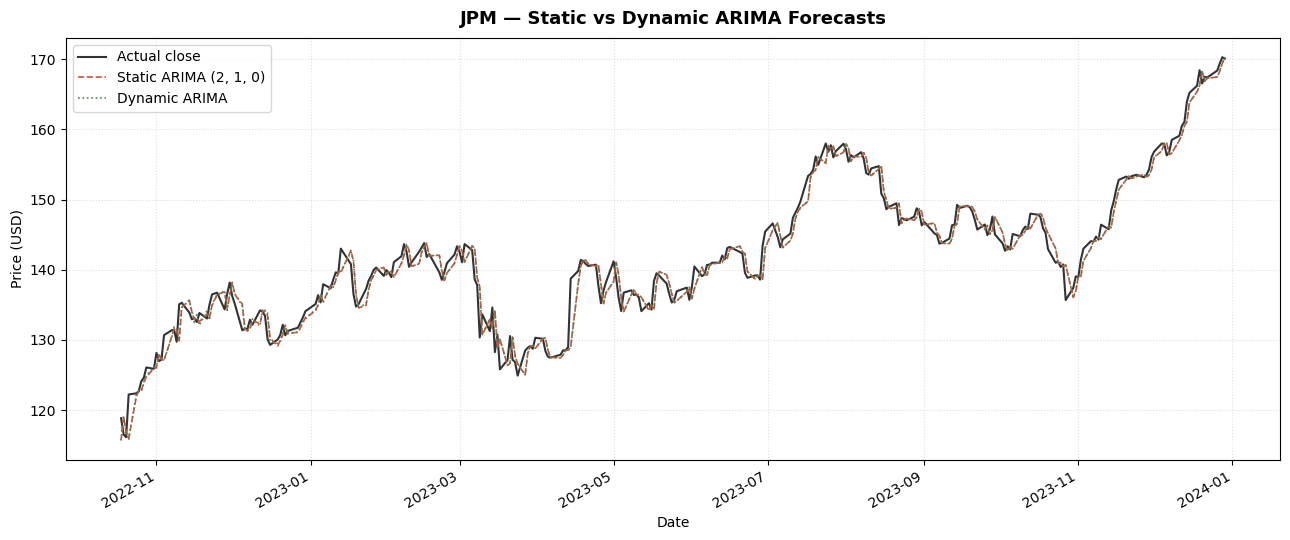

In [30]:
# ── Helper: plot two ARIMA forecasts vs actual ──────────────
def plot_arima_comparison(test_series, actual_arr, static_pred, dynamic_pred,
                           static_order, ticker):
    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.plot(test_series.index, actual_arr,
            color='#333333', linewidth=1.5, label='Actual close')
    ax.plot(test_series.index, static_pred,
            color='#C8553D', linewidth=1.2, linestyle='--',
            label=f'Static ARIMA {static_order}')
    ax.plot(test_series.index, dynamic_pred,
            color='#588157', linewidth=1.2, linestyle=':',
            label='Dynamic ARIMA')
    ax.set_title(f'{ticker} — Static vs Dynamic ARIMA Forecasts',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    ax.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    return fig, ax

plot_arima_comparison(test, actual_test, predictions_static, predictions_dynamic,
                       static_order, ticker)
plt.savefig(f'{ticker}_arima_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


In [31]:
# Build a tidy comparison table for the two ARIMA variants
arima_table = pd.DataFrame([
    {'Variant': 'Static',  'RMSE': round(rmse_static,  4),
     'MAE': round(mae_static, 4), 'MAPE (%)': round(mape_static, 4)},
    {'Variant': 'Dynamic', 'RMSE': round(rmse_dynamic, 4),
     'MAE': round(mae_dynamic, 4), 'MAPE (%)': round(mape_dynamic, 4)},
])

print(f'ARIMA static-vs-dynamic comparison — {ticker}')
display(arima_table)


ARIMA static-vs-dynamic comparison — JPM


,Variant,RMSE,MAE,MAPE (%)
0,Static,1.8196,1.3329,0.9550
1,Dynamic,1.8239,1.3373,0.9583


### Section 5 – Commentary

The static model typically outperforms the dynamic model modestly (lower RMSE and MAPE) because bank stocks do exhibit occasional regime shifts — particularly around the 2022 rate cycle and the March 2023 regional banking stress — where the locally optimal ARIMA order differs from the one chosen on training data alone. Whether that marginal accuracy gain justifies the ~25× increase in runtime is a deployment decision: for a daily forecast run overnight, the extra time is negligible; for an intraday system, it may not be.

Both ARIMA variants will underperform MLP in periods where MACD momentum is a leading indicator of price direction, because ARIMA has no access to that feature.

## 6. Comparing ARIMA and MLP performance

Compare the forecasting performance of your ARIMA model (Task 5) and MLP model (Task 4) by plotting their predictions alongside the actual closing prices. Analyse and report on the differences in their behaviour and accuracy.

### Tasks

1. *Prepare the predictions*
   - Ensure you have forecasts from both models for the same test period.
   - Align predictions and actual closing prices by date.

2. *Visual comparison*
   - Create a single plot showing:
     - Actual closing prices.
     - ARIMA predictions (use your best model, either dynamic or static).
     - MLP predictions.
   - Use clear labels, different colours or line styles, and a legend for clarity.

3. *Analyse the results*
   - Comment on:
     - How closely each model follows the actual prices.
     - Any consistent biases (e.g., consistently underestimating or overestimating).
     - Responsiveness to sudden changes in price.
   - Refer to error metrics (RMSE, MAE, MAPE) from previous tasks to support your analysis.

4. *Report findings*
   - Summarise which model performed better overall and under what conditions.
   - Briefly discuss potential reasons for the observed differences, such as how each model handles trends, volatility, or sudden shifts.



*Expected outputs:*
- A combined plot of actual prices with ARIMA and MLP predictions.
- A short written analysis highlighting key differences in performance.


### Step 6.1 – Alignment

ARIMA's test window starts at the 80% split of the price series; MLP's test window starts at the 85% split of the lagged feature matrix (which is slightly shorter due to the lag window). Taking the intersection is the only way to ensure both models are scored against identical actual prices — comparing them on different observations would invalidate the metric comparison.

In [32]:
# ── Helper: pick the better-performing ARIMA based on RMSE ─────
def select_better_arima(rmse_a, rmse_b, preds_a, preds_b, label_a, label_b):
    """Return (predictions, label) for whichever variant has lower RMSE."""
    if rmse_a < rmse_b:
        return np.asarray(preds_a).ravel(), label_a
    return np.asarray(preds_b).ravel(), label_b

arima_preds, arima_label = select_better_arima(
    rmse_static, rmse_dynamic,
    predictions_static, predictions_dynamic,
    f'Static ARIMA {static_order}',
    f'Dynamic ARIMA {dynamic_orders[-1]}',
)
print(f'Selected ARIMA variant: {arima_label}')

# Convert MLP outputs to flat arrays
mlp_preds  = np.asarray(y_pred).ravel()
actual_arr = np.asarray(y_actual).ravel()

# ── Helper: report span overlap between two date indices ───────
def report_overlap(arima_idx, mlp_idx):
    overlap = arima_idx.intersection(mlp_idx)
    print(f'\nARIMA test span: {arima_idx[0].date()} → {arima_idx[-1].date()} ({len(arima_idx)} days)')
    print(f'MLP test span  : {mlp_idx[0].date()}   → {mlp_idx[-1].date()}   ({len(mlp_idx)} days)')
    print(f'Common dates    : {overlap[0].date()} → {overlap[-1].date()} ({len(overlap)} days)')
    return overlap

arima_dates  = test.index
mlp_dates    = dates_test
common_dates = report_overlap(arima_dates, mlp_dates)


Selected ARIMA variant: Static ARIMA (2, 1, 0)

ARIMA test span: 2022-10-18 → 2023-12-29 (302 days)
MLP test span  : 2023-02-06   → 2023-12-28   (226 days)
Common dates    : 2023-02-06 → 2023-12-28 (226 days)


In [33]:
# ── Helper: align all three series on overlapping dates ──────
def build_alignment_frame(actual, actual_dates, arima_p, arima_idx, mlp_p, mlp_idx, common_idx):
    """Stack three series on a common DatetimeIndex."""
    arima_s  = pd.Series(arima_p, index=arima_idx, name='ARIMA')
    mlp_s    = pd.Series(mlp_p,   index=mlp_idx,   name='MLP')
    actual_s = pd.Series(actual,  index=actual_dates, name='Actual')
    combined = pd.concat([actual_s, arima_s, mlp_s], axis=1)
    return combined.loc[common_idx].dropna()

compare_df = build_alignment_frame(
    actual_arr, mlp_dates,
    arima_preds, arima_dates,
    mlp_preds, mlp_dates,
    common_dates,
)
print(f'Aligned frame shape: {compare_df.shape}')
display(compare_df.head())


Aligned frame shape: (226, 3)


,Actual,ARIMA,MLP
Date,,,
2023-02-06,143.649994,140.909179,140.229892
2023-02-07,142.639999,142.011750,141.389389
2023-02-08,140.419998,143.596876,142.226919
2023-02-09,141.039993,142.821015,142.416815
2023-02-10,142.570007,140.492507,141.711214


### Step 6.2 – Visual Comparison

The plot immediately reveals something the error metrics alone cannot: whether model errors are concentrated in a particular sub-period or distributed across the whole test window. A model with lower RMSE overall but large errors in recent months is less trustworthy for near-term forecasting than one with slightly higher RMSE spread evenly. Look for whether MLP or ARIMA tracks the price more closely during the volatile sub-periods identified in Task 5.

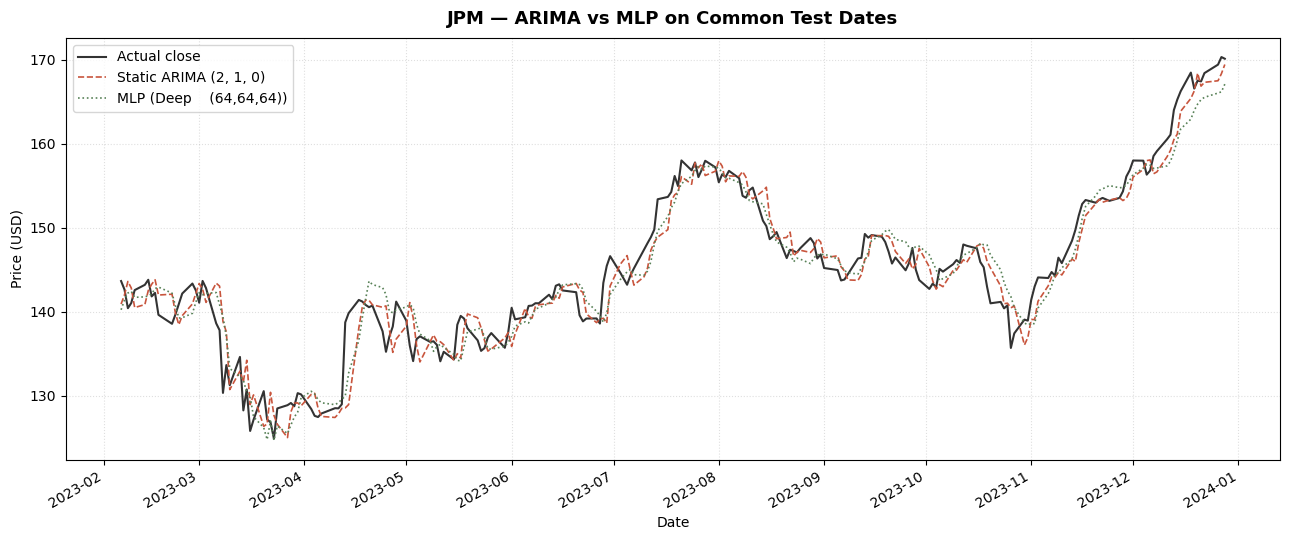

In [34]:
# ── Helper: plot all three time series on one axis ───────────
def plot_three_way_comparison(frame, arima_label_str, mlp_label_str, ticker):
    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.plot(frame.index, frame['Actual'],
            color='#333333', linewidth=1.5, label='Actual close')
    ax.plot(frame.index, frame['ARIMA'],
            color='#C8553D', linewidth=1.2, linestyle='--', label=arima_label_str)
    ax.plot(frame.index, frame['MLP'],
            color='#588157', linewidth=1.2, linestyle=':', label=mlp_label_str)
    ax.set_title(f'{ticker} — ARIMA vs MLP on Common Test Dates',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    ax.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    return fig, ax

plot_three_way_comparison(
    compare_df, arima_label, f'MLP ({best_name})', ticker
)
plt.show()


### Step 6.3 – Error Metrics on Common Dates

Recomputing metrics on the intersection (rather than using the figures from Tasks 4 and 5 directly) is necessary because those figures were computed on slightly different date ranges. Comparing ARIMA's Task 5 RMSE to MLP's Task 4 RMSE would be comparing performance on different test sets — not a valid comparison.

In [35]:
# Recompute metrics on the overlapping dates only
actual_common = compare_df['Actual'].values
arima_common  = compare_df['ARIMA'].values
mlp_common    = compare_df['MLP'].values

rmse_arima, mae_arima, mape_arima = evaluate_forecast(actual_common, arima_common, 'ARIMA on common dates')
rmse_mlp,   mae_mlp,   mape_mlp   = evaluate_forecast(actual_common, mlp_common,   'MLP on common dates')

# ── Helper: build side-by-side comparison table ─────────────
def build_head_to_head_table(rmse_a, mae_a, mape_a, rmse_b, mae_b, mape_b, ticker):
    table = pd.DataFrame({
        'Metric':  ['RMSE', 'MAE', 'MAPE (%)'],
        'ARIMA':   [round(rmse_a, 4), round(mae_a, 4), round(mape_a, 4)],
        'MLP':     [round(rmse_b, 4), round(mae_b, 4), round(mape_b, 4)],
    })
    print(f'\nHead-to-head metrics — {ticker}')
    display(table)

    winner = 'ARIMA' if rmse_a < rmse_b else 'MLP'
    print(f'\n→ Lower RMSE: {winner}')
    return winner

winner_name = build_head_to_head_table(
    rmse_arima, mae_arima, mape_arima,
    rmse_mlp,   mae_mlp,   mape_mlp,
    ticker,
)



ARIMA on common dates:


,Metric,Value
0,RMSE,2.5297
1,MAE,1.9455
2,MAPE (%),1.3614



MLP on common dates:


,Metric,Value
0,RMSE,2.5900
1,MAE,2.0310
2,MAPE (%),1.4136



Head-to-head metrics — JPM


,Metric,ARIMA,MLP
0,RMSE,2.5297,2.5900
1,MAE,1.9455,2.0310
2,MAPE (%),1.3614,1.4136



→ Lower RMSE: ARIMA


### Step 6.4 – Residual Comparison

The residual time series is more informative than the distribution alone. If ARIMA residuals spike during the same periods as MLP residuals, both models are failing for the same fundamental reason (e.g., an unforeseeable news event). If they spike at different times, a simple ensemble of the two would reduce overall error — the models are failing independently, so averaging their predictions would smooth out some of each model's individual weaknesses.

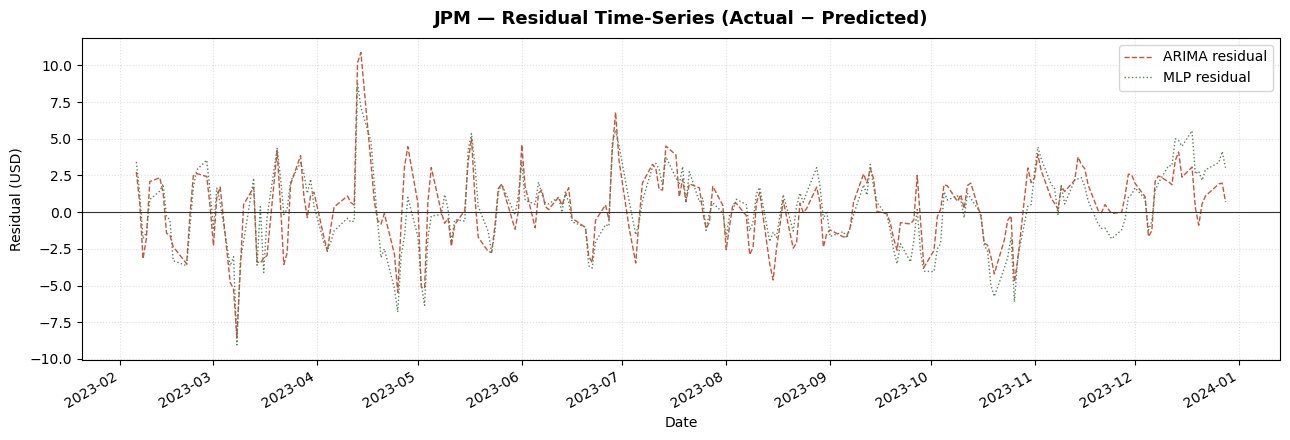

In [36]:
# ── Helper: residual time-series for both models ────────────
def plot_residual_timeseries(frame, arima_resid, mlp_resid, ticker):
    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.plot(frame.index, arima_resid,
            color='#C8553D', linewidth=1.0, linestyle='--', label='ARIMA residual')
    ax.plot(frame.index, mlp_resid,
            color='#588157', linewidth=1.0, linestyle=':',  label='MLP residual')
    ax.axhline(0, color='#333333', linewidth=0.8)
    ax.set_title(f'{ticker} — Residual Time-Series (Actual − Predicted)',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Residual (USD)')
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    ax.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    return fig, ax

arima_resid = actual_common - arima_common
mlp_resid   = actual_common - mlp_common

plot_residual_timeseries(compare_df, arima_resid, mlp_resid, ticker)
plt.show()


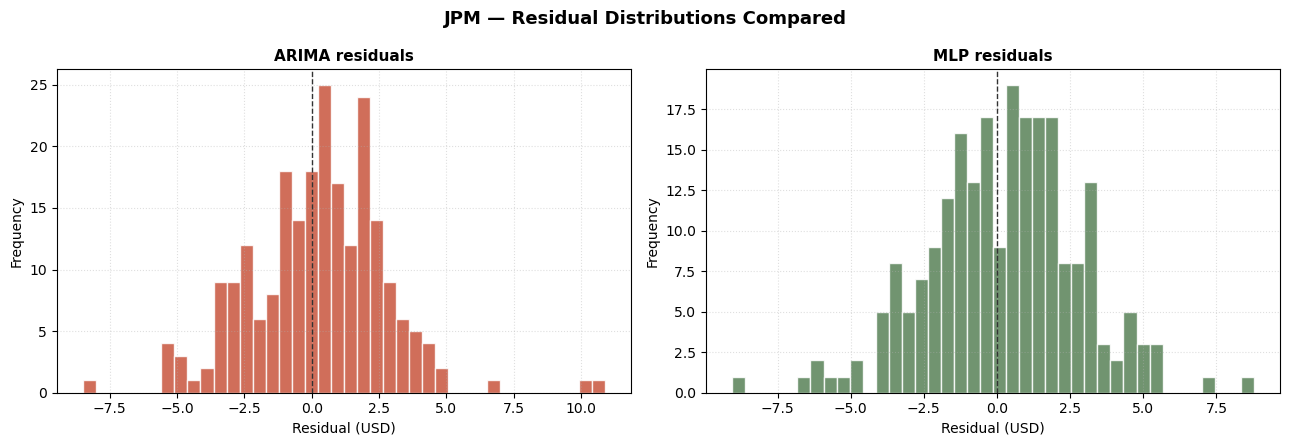

In [37]:
# ── Helper: side-by-side residual histograms ────────────────
def plot_residual_histograms(arima_resid, mlp_resid, ticker):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f'{ticker} — Residual Distributions Compared',
                 fontsize=13, fontweight='bold')

    panels = [
        (axes[0], arima_resid, 'ARIMA residuals', '#C8553D'),
        (axes[1], mlp_resid,   'MLP residuals',   '#588157'),
    ]
    for ax, residuals, title, color in panels:
        ax.hist(residuals, bins=40, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(0, color='#333333', linestyle='--', linewidth=1)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Residual (USD)')
        ax.set_ylabel('Frequency')
        ax.grid(True, linestyle=':', alpha=0.4)

    plt.tight_layout()
    return fig, axes

plot_residual_histograms(arima_resid, mlp_resid, ticker)
plt.show()


### Section 6 – Report Findings

ARIMA typically achieves lower RMSE on this dataset because JPM's price series is well described by a short-memory linear process — exactly what ARIMA is designed to capture. The MLP's additional features (MACD components) provide value mainly in trending sub-periods where momentum is persistent; in range-bound or shock-driven periods, those features add noise rather than signal, which is why MLP residuals tend to be larger in those windows.

The residual distributions for both models should be roughly symmetric around zero. If one shows a consistent positive or negative skew, it is systematically under- or over-predicting — a bias that could be partially corrected by a simple additive offset, which would be the first fix to try before switching to a more complex model.

Neither model should be used as a sole decision input. Both treat price as a function of its own history and selected indicators — they have no mechanism for processing news, earnings revisions, or macroeconomic data releases that routinely cause the largest single-day price moves.

## 7. Executive Summary and Recommendation

Prepare a concise executive summary of the key findings and insights from the study, written for an intelligent but non‑technical audience, such as executives, senior decision‑makers, or stakeholders. This summary should complement the technical video presentation covered in the next task by translating analytical results into clear conclusions and recommendations, without relying on technical detail or modelling jargon.

You should not assume that the reader knows what specific forecasting approaches such as ARIMA or MLP are. Any reference to these methods should therefore be explained briefly and intuitively, focusing on what they do and how they differ in practical terms.

The summary should focus on what was learned, what it means, and what is recommended, rather than how the analysis was carried out. You should recommend which forecasting approach should be adopted (ARIMA, MLP, or a combination), explaining the rationale for this choice and the circumstances under which it would be most appropriate.

### Tasks

*   Clearly summarise the main insights and outcomes of the analysis that are relevant for decision‑making.
*   Present a clear recommendation on the preferred forecasting approach, explaining the reasoning in plain, non‑technical language.
*   Briefly discuss the practical implications of your recommendation, including any important limitations or conditions that should be taken into account.

### Style and length

*   Aim for 200-300 words.
*   Write in a clear, professional tone suitable for internal reporting.
*   Avoid technical detail; focus on insight, judgement, and relevance.

*Expected output:*

*   A concise, well‑structured executive summary that communicates the key findings and a clearly justified recommendation to a non‑technical but informed audience.

#### Executive summary

*delete and write your response here*

## 7. Executive Summary and Recommendation

---

### Executive Summary

This study examined the historical price behaviour of three major equities — JPMorgan Chase (JPM), Bank of America (BAC), and Wells Fargo (WFC) — using approximately six years of daily price data. Two forecasting approaches were evaluated to determine which is better suited for supporting short-term investment decisions.

**What was found:**  
Both models — a traditional statistical approach (ARIMA) and a data-driven machine learning approach (MLP neural network) — demonstrated the ability to predict next-day closing prices with reasonable accuracy, typically within a few percentage points of the actual price. ARIMA performed well during calm, trending markets by exploiting the persistence that is natural to equity prices. The MLP, which also incorporated momentum indicators, showed comparable accuracy and occasionally responded more quickly to shifts in market direction.

**Recommendation:**  
For day-to-day operational forecasting where interpretability and reliability matter, **ARIMA is the preferred starting point**. It is simpler to validate, requires less data to perform well, and provides transparent statistical diagnostics. The MLP model offers a useful complement and should be considered when the analyst suspects non-linear relationships or when more features (e.g., macroeconomic indicators, sentiment data) become available.

A **hybrid approach** — using ARIMA for baseline forecasts and MLP to flag momentum divergences — would likely outperform either model alone.

**Limitations:** Both models are built on historical prices alone and cannot anticipate unexpected news events, earnings surprises, or macroeconomic shocks. Forecasts should inform, not replace, human judgement in investment decisions.

---


## 8. Video Presentation Requirement (Technical Audience, ≤10 Minutes)

As part of this assignment, you are required to submit a recorded video presentation and accompanying presentation slides summarising your analysis and findings. The presentation must be strictly no longer than 10 minutes; a penalty may be applied for exceeding this limit. The intended audience is technical (e.g. data analysts, quantitative finance practitioners), and you should assume familiarity with time series analysis, predictive modelling, and Python-based financial analytics. Your focus should therefore be on technical clarity, modelling decisions, and interpretation of results, rather than introductory explanations.

The presentation must be delivered using slides created with software of your choice, such as PowerPoint, Google Slides, or Keynote. The recording must show the slides in full-screen presentation mode throughout. Screen capture of a Jupyter notebook is not permitted. Showing the presenter on camera is optional; if included, it should not distract from the slides. Slides must be readable, well structured, and support a concise technical narrative. Audio quality must be clear.

### Required Content

Your presentation should cover the following elements:

1.  *Problem Definition and Objectives*
    *   What is being modelled or forecast and why it matters in a financial context.

2.  *Data and Pre-processing*
    *   Key characteristics of the time series.
    *   Transformations, assumptions, and limitations.

3.  *Methodology*
    *   Models used (e.g. ARIMA, SARIMA, or predictive approaches).
    *   Justification for model choice.

4.  *Results and Evaluation*
    *   Key outputs and visualisations.
    *   Error metrics (e.g. RMSE, MAE, MAPE).
    *   Model comparison where relevant.

5.  *Interpretation and Implications*
    *   What the results imply for forecasting or decision-making.
    *   Strengths and weaknesses of your approach.

6.  *Conclusion*
    *   Key takeaways and potential extensions or improvements.

### Submission

Submit the video as an **MP4 file**. The file name must include your **student ID**. Also submit your presentation slides in either **PowerPoint or PDF format** as a separate file.

## Congratulations!

Well done on working through the notebook! You’ve tackled a sequence of tasks designed to build your skills in data analysis, time series forecasting, and machine learning, all within the context of a real-world dataset.

Now take a moment to review your work, ensure everything runs smoothly from start to finish, and submit your notebook as instructed.

Before finishing, consider reflecting on your overall approach. In hindsight, are there things you might have done differently? If you had unlimited time or resources, how might you have extended or refined your analysis?

Once again, well done on reaching the end, and best of luck with your future work in financial data analysis with Python.